# 20. Ejercicio integrado: concentraciones horarias de ozono

Datos: https://github.com/jamc88/TSMA-II-26-O/raw/refs/heads/main/Datos/2026O3.xls

En esta sección aplicaremos los conceptos desarrollados durante la clase a un conjunto de datos real de concentraciones de ozono registradas en diferentes estaciones de monitoreo.

La base contiene dos variables que identifican el tiempo:

- `FECHA`;
- `HORA`;

y un conjunto de columnas correspondientes a diferentes estaciones de monitoreo:

$$
\text{ACO},\text{AJM},\text{AJU},\ldots,\text{VIF},\text{XAL}.
$$

Cada valor puede interpretarse de manera general como

$$
X_{i,t},
$$

donde $i$ identifica la estación de monitoreo y $t$ el instante de observación.

Por tanto, la base contiene simultáneamente múltiples series temporales.

## Objetivo

Nuestro propósito será determinar si los datos presentan una estructura temporal adecuada antes de utilizarlos en análisis posteriores.

Seguiremos el procedimiento:

$$
\boxed{
\text{archivo original}
\rightarrow
\text{fecha y hora}
\rightarrow
\text{índice temporal}
\rightarrow
\text{regularidad}
\rightarrow
\text{cobertura}
\rightarrow
\text{estructura por estación}
}
$$

En particular, responderemos:

1. ¿Cuál es el periodo cubierto por la base?
2. ¿Cuál es la frecuencia temporal de las mediciones?
3. ¿Existen instantes duplicados?
4. ¿Existen horas faltantes?
5. ¿Todas las estaciones tienen la misma cobertura?
6. ¿Qué estaciones presentan mayor cantidad de datos faltantes?
7. ¿Los faltantes aparecen aislados o forman huecos consecutivos?
8. ¿Cómo podemos transformar la base de formato ancho a un panel estación--tiempo?
9. ¿Cómo cambia la información al pasar de frecuencia horaria a diaria?

El objetivo no será corregir inmediatamente los problemas encontrados, sino realizar primero un diagnóstico reproducible de la calidad temporal del conjunto de datos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://github.com/jamc88/TSMA-II-26-O/raw/refs/heads/main/Datos/2026O3.xls"

df_o3 = pd.read_excel(url)

print("Dimensiones del dataset:")
print(df_o3.shape)

df_o3.head()

Dimensiones del dataset:
(1416, 38)


,FECHA,HORA,ACO,AJM,AJU,ATI,BJU,CAM,CCA,CHO,...,SAG,SFE,SJA,TAH,TLA,TLI,UAX,UIZ,VIF,XAL
0,2026-01-01,1,-99,19,-99,18,17,4,13,-99,...,19,-99,-99,-99,5,10,23,14,4,4
1,2026-01-01,2,-99,23,-99,11,14,5,9,-99,...,5,-99,-99,-99,6,6,11,5,7,5
2,2026-01-01,3,-99,30,-99,13,5,5,10,-99,...,3,-99,-99,-99,7,6,1,2,9,4
3,2026-01-01,4,-99,34,-99,8,4,3,8,-99,...,3,-99,-99,-99,5,6,2,3,9,5
4,2026-01-01,5,-99,36,-99,4,5,3,5,-99,...,3,-99,-99,-99,8,8,2,3,8,5


In [3]:
print("\nNombres de las columnas:")
print(df_o3.columns.tolist())

print("\nTipos de datos:")
print(df_o3.dtypes)

print("\nNúmero total de columnas:")
print(df_o3.shape[1])

print("\nNúmero de estaciones:")
print(df_o3.shape[1] - 2)


Nombres de las columnas:
['FECHA', 'HORA', 'ACO', 'AJM', 'AJU', 'ATI', 'BJU', 'CAM', 'CCA', 'CHO', 'COY', 'CUA', 'CUT', 'FAC', 'FAR', 'GAM', 'HGM', 'INN', 'IZT', 'LLA', 'LPR', 'MER', 'MGH', 'MON', 'MPA', 'NEZ', 'PED', 'SAC', 'SAG', 'SFE', 'SJA', 'TAH', 'TLA', 'TLI', 'UAX', 'UIZ', 'VIF', 'XAL']

Tipos de datos:
FECHA    datetime64[ns]
HORA              int64
ACO               int64
AJM               int64
AJU               int64
ATI               int64
BJU               int64
CAM               int64
CCA               int64
CHO               int64
COY               int64
CUA               int64
CUT               int64
FAC               int64
FAR               int64
GAM               int64
HGM               int64
INN               int64
IZT               int64
LLA               int64
LPR               int64
MER               int64
MGH               int64
MON               int64
MPA               int64
NEZ               int64
PED               int64
SAC               int64
SAG            

## 21. Valores faltantes codificados

Antes de analizar las mediciones es necesario identificar cómo representa la fuente original a los datos faltantes.

De acuerdo con el diccionario de datos, el valor

$$
-99
$$

no representa una concentración de ozono, sino una **medición no disponible**.

Por tanto, debemos realizar la transformación

$$
-99 \longrightarrow \mathrm{NaN}.
$$

Esta corrección debe hacerse antes de calcular estadísticas descriptivas, cobertura temporal o cualquier otro indicador.

Si mantuviéramos los valores $-99$ como observaciones válidas, cantidades como la media

$$
\bar{x}=\frac{1}{n}\sum_{t=1}^{n}x_t
$$

quedarían artificialmente reducidas y dejarían de representar el comportamiento real de la concentración de ozono.

En este conjunto de datos las columnas `FECHA` y `HORA` describen el tiempo, mientras que las columnas restantes corresponden a estaciones de monitoreo. Por ello, la sustitución de `-99` por `NaN` se realizará **únicamente sobre las columnas de las estaciones**.

Antes de efectuar el reemplazo contaremos cuántos valores `-99` presenta cada estación. Esto nos dará una primera idea de la disponibilidad de información en la base.

In [4]:
estaciones = [
    columna for columna in df_o3.columns
    if columna not in ["FECHA", "HORA"]
]


# Conteo de valores -99 por estación
valores_menos_99 = (
    df_o3[estaciones]
    .eq(-99)
    .sum()
    .sort_values(ascending=False)
)

valores_menos_99

IZT    1416
AJU    1416
SJA    1416
CHO    1416
COY    1416
SFE    1416
FAR    1416
MPA    1416
CAM    1305
TAH     917
SAC     820
CUA     769
TLI     458
ACO     366
MON     286
SAG     281
XAL     240
CCA     234
NEZ     135
BJU     129
LPR     119
MER     110
TLA      98
VIF      96
INN      78
GAM      69
CUT      69
UAX      61
ATI      52
LLA      52
AJM      49
UIZ      45
HGM      38
FAC      38
PED      37
MGH      37
dtype: int64

In [5]:
print("\nNúmero total de valores -99:")
valores_menos_99.sum()


Número total de valores -99:


18316

In [6]:
# Sustitución de -99 por NaN
df_o3[estaciones] = df_o3[estaciones].replace(-99, np.nan)


print("\nNúmero total de valores NaN:")
print(df_o3[estaciones].isna().sum().sum())

df_o3.head()


Número total de valores NaN:
18316


,FECHA,HORA,ACO,AJM,AJU,ATI,BJU,CAM,CCA,CHO,...,SAG,SFE,SJA,TAH,TLA,TLI,UAX,UIZ,VIF,XAL
0,2026-01-01,1,NaN,19.0,NaN,18.0,17.0,4.0,13.0,NaN,...,19.0,NaN,NaN,NaN,5.0,10.0,23.0,14.0,4.0,4.0
1,2026-01-01,2,NaN,23.0,NaN,11.0,14.0,5.0,9.0,NaN,...,5.0,NaN,NaN,NaN,6.0,6.0,11.0,5.0,7.0,5.0
2,2026-01-01,3,NaN,30.0,NaN,13.0,5.0,5.0,10.0,NaN,...,3.0,NaN,NaN,NaN,7.0,6.0,1.0,2.0,9.0,4.0
3,2026-01-01,4,NaN,34.0,NaN,8.0,4.0,3.0,8.0,NaN,...,3.0,NaN,NaN,NaN,5.0,6.0,2.0,3.0,9.0,5.0
4,2026-01-01,5,NaN,36.0,NaN,4.0,5.0,3.0,5.0,NaN,...,3.0,NaN,NaN,NaN,8.0,8.0,2.0,3.0,8.0,5.0


## 22. Construcción de la variable temporal

La base almacena el tiempo mediante dos columnas:

- `FECHA`, que identifica el día;
- `HORA`, que identifica la hora de la medición.

Para trabajar con herramientas de series temporales necesitamos combinar ambas variables en un único instante

$$
t = \text{FECHA} + \text{HORA}.
$$

En esta base, la variable `HORA` utiliza valores de $1$ a $24$. Por ejemplo,

$$
\text{FECHA}=2026\text{-}01\text{-}01,
\qquad
\text{HORA}=1
$$

corresponde a

$$
2026\text{-}01\text{-}01\ 01{:}00.
$$

Mientras que

$$
\text{HORA}=24
$$

corresponde al inicio del día siguiente:

$$
2026\text{-}01\text{-}01 + 24\text{ h}
=
2026\text{-}01\text{-}02\ 00{:}00.
$$

Crearemos una nueva variable denominada `timestamp` y posteriormente verificaremos:

1. que todas las fechas pudieron convertirse correctamente;
2. que las observaciones estén ordenadas cronológicamente;
3. que no existan instantes duplicados;
4. cuál es el primer y último instante disponible.

Todavía no estableceremos `timestamp` como índice. Primero verificaremos que la construcción sea correcta.

**pd.to_timedelta()** convierte cadenas de texto, números enteros o de punto flotante, y estructuras iterables (listas, Series o arrays) en objetos de tipo Timedelta (o TimedeltaIndex), que representan duraciones o intervalos de tiempo en pandas.

In [7]:
o3 = df_o3.copy()


# Construcción del timestamp

o3["FECHA"] = pd.to_datetime(o3["FECHA"],errors="coerce")

o3["timestamp"] = o3["FECHA"] + pd.to_timedelta(o3["HORA"], unit="h")



# Orden cronológico
o3 = o3.sort_values("timestamp").reset_index(drop=True)

o3.head()

,FECHA,HORA,ACO,AJM,AJU,ATI,BJU,CAM,CCA,CHO,...,SFE,SJA,TAH,TLA,TLI,UAX,UIZ,VIF,XAL,timestamp
0,2026-01-01,1,NaN,19.0,NaN,18.0,17.0,4.0,13.0,NaN,...,NaN,NaN,NaN,5.0,10.0,23.0,14.0,4.0,4.0,2026-01-01 01:00:00
1,2026-01-01,2,NaN,23.0,NaN,11.0,14.0,5.0,9.0,NaN,...,NaN,NaN,NaN,6.0,6.0,11.0,5.0,7.0,5.0,2026-01-01 02:00:00
2,2026-01-01,3,NaN,30.0,NaN,13.0,5.0,5.0,10.0,NaN,...,NaN,NaN,NaN,7.0,6.0,1.0,2.0,9.0,4.0,2026-01-01 03:00:00
3,2026-01-01,4,NaN,34.0,NaN,8.0,4.0,3.0,8.0,NaN,...,NaN,NaN,NaN,5.0,6.0,2.0,3.0,9.0,5.0,2026-01-01 04:00:00
4,2026-01-01,5,NaN,36.0,NaN,4.0,5.0,3.0,5.0,NaN,...,NaN,NaN,NaN,8.0,8.0,2.0,3.0,8.0,5.0,2026-01-01 05:00:00


In [8]:
o3[["FECHA", "HORA", "timestamp"]].tail(10)

,FECHA,HORA,timestamp
1406,2026-02-28,15,2026-02-28 15:00:00
1407,2026-02-28,16,2026-02-28 16:00:00
1408,2026-02-28,17,2026-02-28 17:00:00
1409,2026-02-28,18,2026-02-28 18:00:00
1410,2026-02-28,19,2026-02-28 19:00:00
1411,2026-02-28,20,2026-02-28 20:00:00
1412,2026-02-28,21,2026-02-28 21:00:00
1413,2026-02-28,22,2026-02-28 22:00:00
1414,2026-02-28,23,2026-02-28 23:00:00
1415,2026-02-28,24,2026-03-01 00:00:00


In [9]:
print("\nValores de timestamp que no pudieron construirse:")
print(o3["timestamp"].isna().sum())

print("\nPrimer instante:")
print(o3["timestamp"].min())

print("\nÚltimo instante:")
print(o3["timestamp"].max())

print("\nNúmero de timestamps duplicados:")
print(o3["timestamp"].duplicated().sum())


Valores de timestamp que no pudieron construirse:
0

Primer instante:
2026-01-01 01:00:00

Último instante:
2026-03-01 00:00:00

Número de timestamps duplicados:
0


## 23. Verificación de la frecuencia temporal

Una vez construida la variable `timestamp`, podemos estudiar la separación entre observaciones consecutivas.

Definimos

$$
\Delta t_i=t_i-t_{i-1}.
$$

Si la base contiene observaciones horarias regulares, esperamos encontrar

$$
\Delta t_i=1\text{ hora}
$$

para todos los pares de observaciones consecutivas.

Este paso permite detectar:

- horas faltantes;
- saltos temporales;
- cambios de frecuencia;
- errores en la construcción del `timestamp`.

También utilizaremos `pd.infer_freq()` para verificar si `pandas` reconoce automáticamente una frecuencia horaria.

Si toda la secuencia es regular, entonces podremos afirmar que el **calendario temporal está completo**.

Esto no significa necesariamente que todas las estaciones tengan mediciones disponibles. Una estación puede tener valores `NaN` aunque el instante temporal correspondiente exista en la base.

Por tanto, debemos distinguir entre

$$
\boxed{\text{faltantes en el calendario temporal}}
$$

y

$$
\boxed{\text{faltantes en las mediciones de una estación}}.
$$

In [10]:
# Índice temporal
o3_temporal = o3.set_index("timestamp").sort_index()
o3_temporal.head()

,FECHA,HORA,ACO,AJM,AJU,ATI,BJU,CAM,CCA,CHO,...,SAG,SFE,SJA,TAH,TLA,TLI,UAX,UIZ,VIF,XAL
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-01-01 01:00:00,2026-01-01,1,NaN,19.0,NaN,18.0,17.0,4.0,13.0,NaN,...,19.0,NaN,NaN,NaN,5.0,10.0,23.0,14.0,4.0,4.0
2026-01-01 02:00:00,2026-01-01,2,NaN,23.0,NaN,11.0,14.0,5.0,9.0,NaN,...,5.0,NaN,NaN,NaN,6.0,6.0,11.0,5.0,7.0,5.0
2026-01-01 03:00:00,2026-01-01,3,NaN,30.0,NaN,13.0,5.0,5.0,10.0,NaN,...,3.0,NaN,NaN,NaN,7.0,6.0,1.0,2.0,9.0,4.0
2026-01-01 04:00:00,2026-01-01,4,NaN,34.0,NaN,8.0,4.0,3.0,8.0,NaN,...,3.0,NaN,NaN,NaN,5.0,6.0,2.0,3.0,9.0,5.0
2026-01-01 05:00:00,2026-01-01,5,NaN,36.0,NaN,4.0,5.0,3.0,5.0,NaN,...,3.0,NaN,NaN,NaN,8.0,8.0,2.0,3.0,8.0,5.0


In [11]:
frecuencia_inferida = pd.infer_freq(o3_temporal.index)

print("Frecuencia inferida:")
frecuencia_inferida

Frecuencia inferida:


'h'

In [12]:
# Diferencias entre observaciones consecutivas

delta_t = o3_temporal.index.to_series().diff()
delta_t

timestamp
2026-01-01 01:00:00               NaT
2026-01-01 02:00:00   0 days 01:00:00
2026-01-01 03:00:00   0 days 01:00:00
2026-01-01 04:00:00   0 days 01:00:00
2026-01-01 05:00:00   0 days 01:00:00
                            ...      
2026-02-28 20:00:00   0 days 01:00:00
2026-02-28 21:00:00   0 days 01:00:00
2026-02-28 22:00:00   0 days 01:00:00
2026-02-28 23:00:00   0 days 01:00:00
2026-03-01 00:00:00   0 days 01:00:00
Name: timestamp, Length: 1416, dtype: timedelta64[ns]

In [13]:
print("\nIntervalos observados:")
delta_t.dropna().value_counts().sort_index()


Intervalos observados:


timestamp
0 days 01:00:00    1415
Name: count, dtype: int64

In [15]:
# Verificación de intervalos horarios

n_intervalos = delta_t.notna().sum()

n_intervalos_horarios = (
    delta_t == pd.Timedelta(hours=1)).sum()

porcentaje_horario = n_intervalos_horarios / n_intervalos * 100

print(f"\nNúmero de intervalos evaluados: {n_intervalos}")
print(f"Porcentaje de intervalos horarios: {porcentaje_horario:.2f}%")


Número de intervalos evaluados: 1415
Porcentaje de intervalos horarios: 100.00%


## 24. Cobertura de datos por estación

El calendario temporal del conjunto de datos es completamente regular: los $1415$ intervalos entre observaciones consecutivas tienen una duración de una hora.

Por tanto, sabemos que existen

$$
T=1416
$$

instantes horarios esperados para cada estación.

Sin embargo, una estación puede no disponer de una medición válida en todos esos instantes. Recordemos que los valores originalmente codificados como `-99` fueron transformados a `NaN`.

Para cada estación $i$ calcularemos:

- número de observaciones esperadas;
- número de observaciones disponibles;
- número de observaciones faltantes;
- porcentaje de cobertura.

Definimos la cobertura como

$$
C_i=
\frac{n_i}{T}\times 100,
$$

donde:

- $n_i$ es el número de observaciones válidas de la estación $i$;
- $T$ es el número total de horas esperadas.

Por ejemplo, una cobertura de

$$
C_i=95\%
$$

significa que la estación dispone de información para el $95\%$ de las horas del periodo.

Este indicador permite detectar estaciones con problemas importantes de disponibilidad antes de realizar análisis estadísticos o construir modelos.

Es importante notar que una buena cobertura **no garantiza** por sí sola una buena calidad temporal: dos estaciones pueden tener el mismo porcentaje de datos disponibles, pero una puede presentar faltantes aislados y otra un único hueco de varios días consecutivos. 

In [16]:
# Cobertura de datos por estación

n_horas_esperadas = len(o3_temporal)

cobertura = pd.DataFrame({
    "n_esperadas": n_horas_esperadas,
    "n_disponibles": o3_temporal[estaciones].notna().sum(),
    "n_faltantes": o3_temporal[estaciones].isna().sum()
})

cobertura["cobertura_pct"] = (
    cobertura["n_disponibles"]
    / cobertura["n_esperadas"]
    * 100
)

cobertura = cobertura.sort_values("cobertura_pct", ascending=False)
cobertura.round(2)

,n_esperadas,n_disponibles,n_faltantes,cobertura_pct
PED,1416,1379,37,97.39
MGH,1416,1379,37,97.39
HGM,1416,1378,38,97.32
FAC,1416,1378,38,97.32
UIZ,1416,1371,45,96.82
AJM,1416,1367,49,96.54
ATI,1416,1364,52,96.33
LLA,1416,1364,52,96.33
UAX,1416,1355,61,95.69
CUT,1416,1347,69,95.13


In [17]:
cobertura["cobertura_pct"].describe().round(2)

count    36.00
mean     64.07
std      40.06
min       0.00
25%      28.39
50%      86.97
75%      95.27
max      97.39
Name: cobertura_pct, dtype: float64

In [18]:
print("\nEstaciones con cobertura mayor o igual al 90%:")
cobertura[cobertura["cobertura_pct"] >= 90].round(2)


Estaciones con cobertura mayor o igual al 90%:


,n_esperadas,n_disponibles,n_faltantes,cobertura_pct
PED,1416,1379,37,97.39
MGH,1416,1379,37,97.39
HGM,1416,1378,38,97.32
FAC,1416,1378,38,97.32
UIZ,1416,1371,45,96.82
AJM,1416,1367,49,96.54
ATI,1416,1364,52,96.33
LLA,1416,1364,52,96.33
UAX,1416,1355,61,95.69
CUT,1416,1347,69,95.13


In [19]:
print("\nEstaciones con cobertura menor al 90%:")
cobertura[cobertura["cobertura_pct"] < 90].round(2)


Estaciones con cobertura menor al 90%:


,n_esperadas,n_disponibles,n_faltantes,cobertura_pct
CCA,1416,1182,234,83.47
XAL,1416,1176,240,83.05
SAG,1416,1135,281,80.16
MON,1416,1130,286,79.80
ACO,1416,1050,366,74.15
TLI,1416,958,458,67.66
CUA,1416,647,769,45.69
SAC,1416,596,820,42.09
TAH,1416,499,917,35.24
CAM,1416,111,1305,7.84


## 25. Longitud de los huecos temporales

Dos estaciones pueden tener porcentajes de cobertura similares y, sin embargo, presentar estructuras de faltantes muy diferentes.

Por ejemplo, una estación puede tener 48 observaciones faltantes distribuidas de manera aislada:

$$
\cdots,\; x_t,\; \mathrm{NaN},\; x_{t+2},\; \cdots
$$

mientras que otra puede presentar las mismas 48 observaciones faltantes en un único bloque consecutivo:

$$
\underbrace{
\mathrm{NaN},\mathrm{NaN},\ldots,\mathrm{NaN}
}_{48\text{ horas}}.
$$

Aunque ambas estaciones tengan la misma cobertura, el segundo caso representa una interrupción de dos días completos y puede tener consecuencias mucho más importantes para el análisis temporal.

Para cada estación calcularemos:

- número total de valores faltantes;
- número de huecos o bloques de faltantes;
- longitud del hueco más largo.

Como las observaciones tienen frecuencia horaria, un hueco de longitud $g$ corresponde directamente a

$$
g\text{ horas consecutivas}.
$$

También podemos expresar esta duración en días mediante

$$
G_{\mathrm{días}}
=
\frac{G_{\mathrm{horas}}}{24}.
$$

Este análisis nos permitirá distinguir entre:

$$
\boxed{\text{faltantes aislados}}
\qquad\text{y}\qquad
\boxed{\text{interrupciones prolongadas}}.
$$

Las estaciones sin ninguna observación válida aparecerán con un hueco máximo de $1416$ horas, es decir, todo el periodo de estudio.

###  `faltante.ne(faltante.shift())`

Esta combinación detecta **cambios de estado** fila a fila para aislar bloques consecutivos (*Run-Length Encoding*).

* **`faltante.shift()`**: Desplaza la columna una fila hacia abajo para comparar cada valor con el inmediatamente anterior.
* **`.ne(...)`**: Evalúa desigualdad (`!=`). Devuelve `True` exclusivamente cuando hay una transición de estado (`Dato -> NaN` o `NaN -> Dato`).
* **`.cumsum()`**: Suma acumulativa sobre booleanos (`True = 1`, `False = 0`). Asigna un identificador numérico único a cada racha continua.

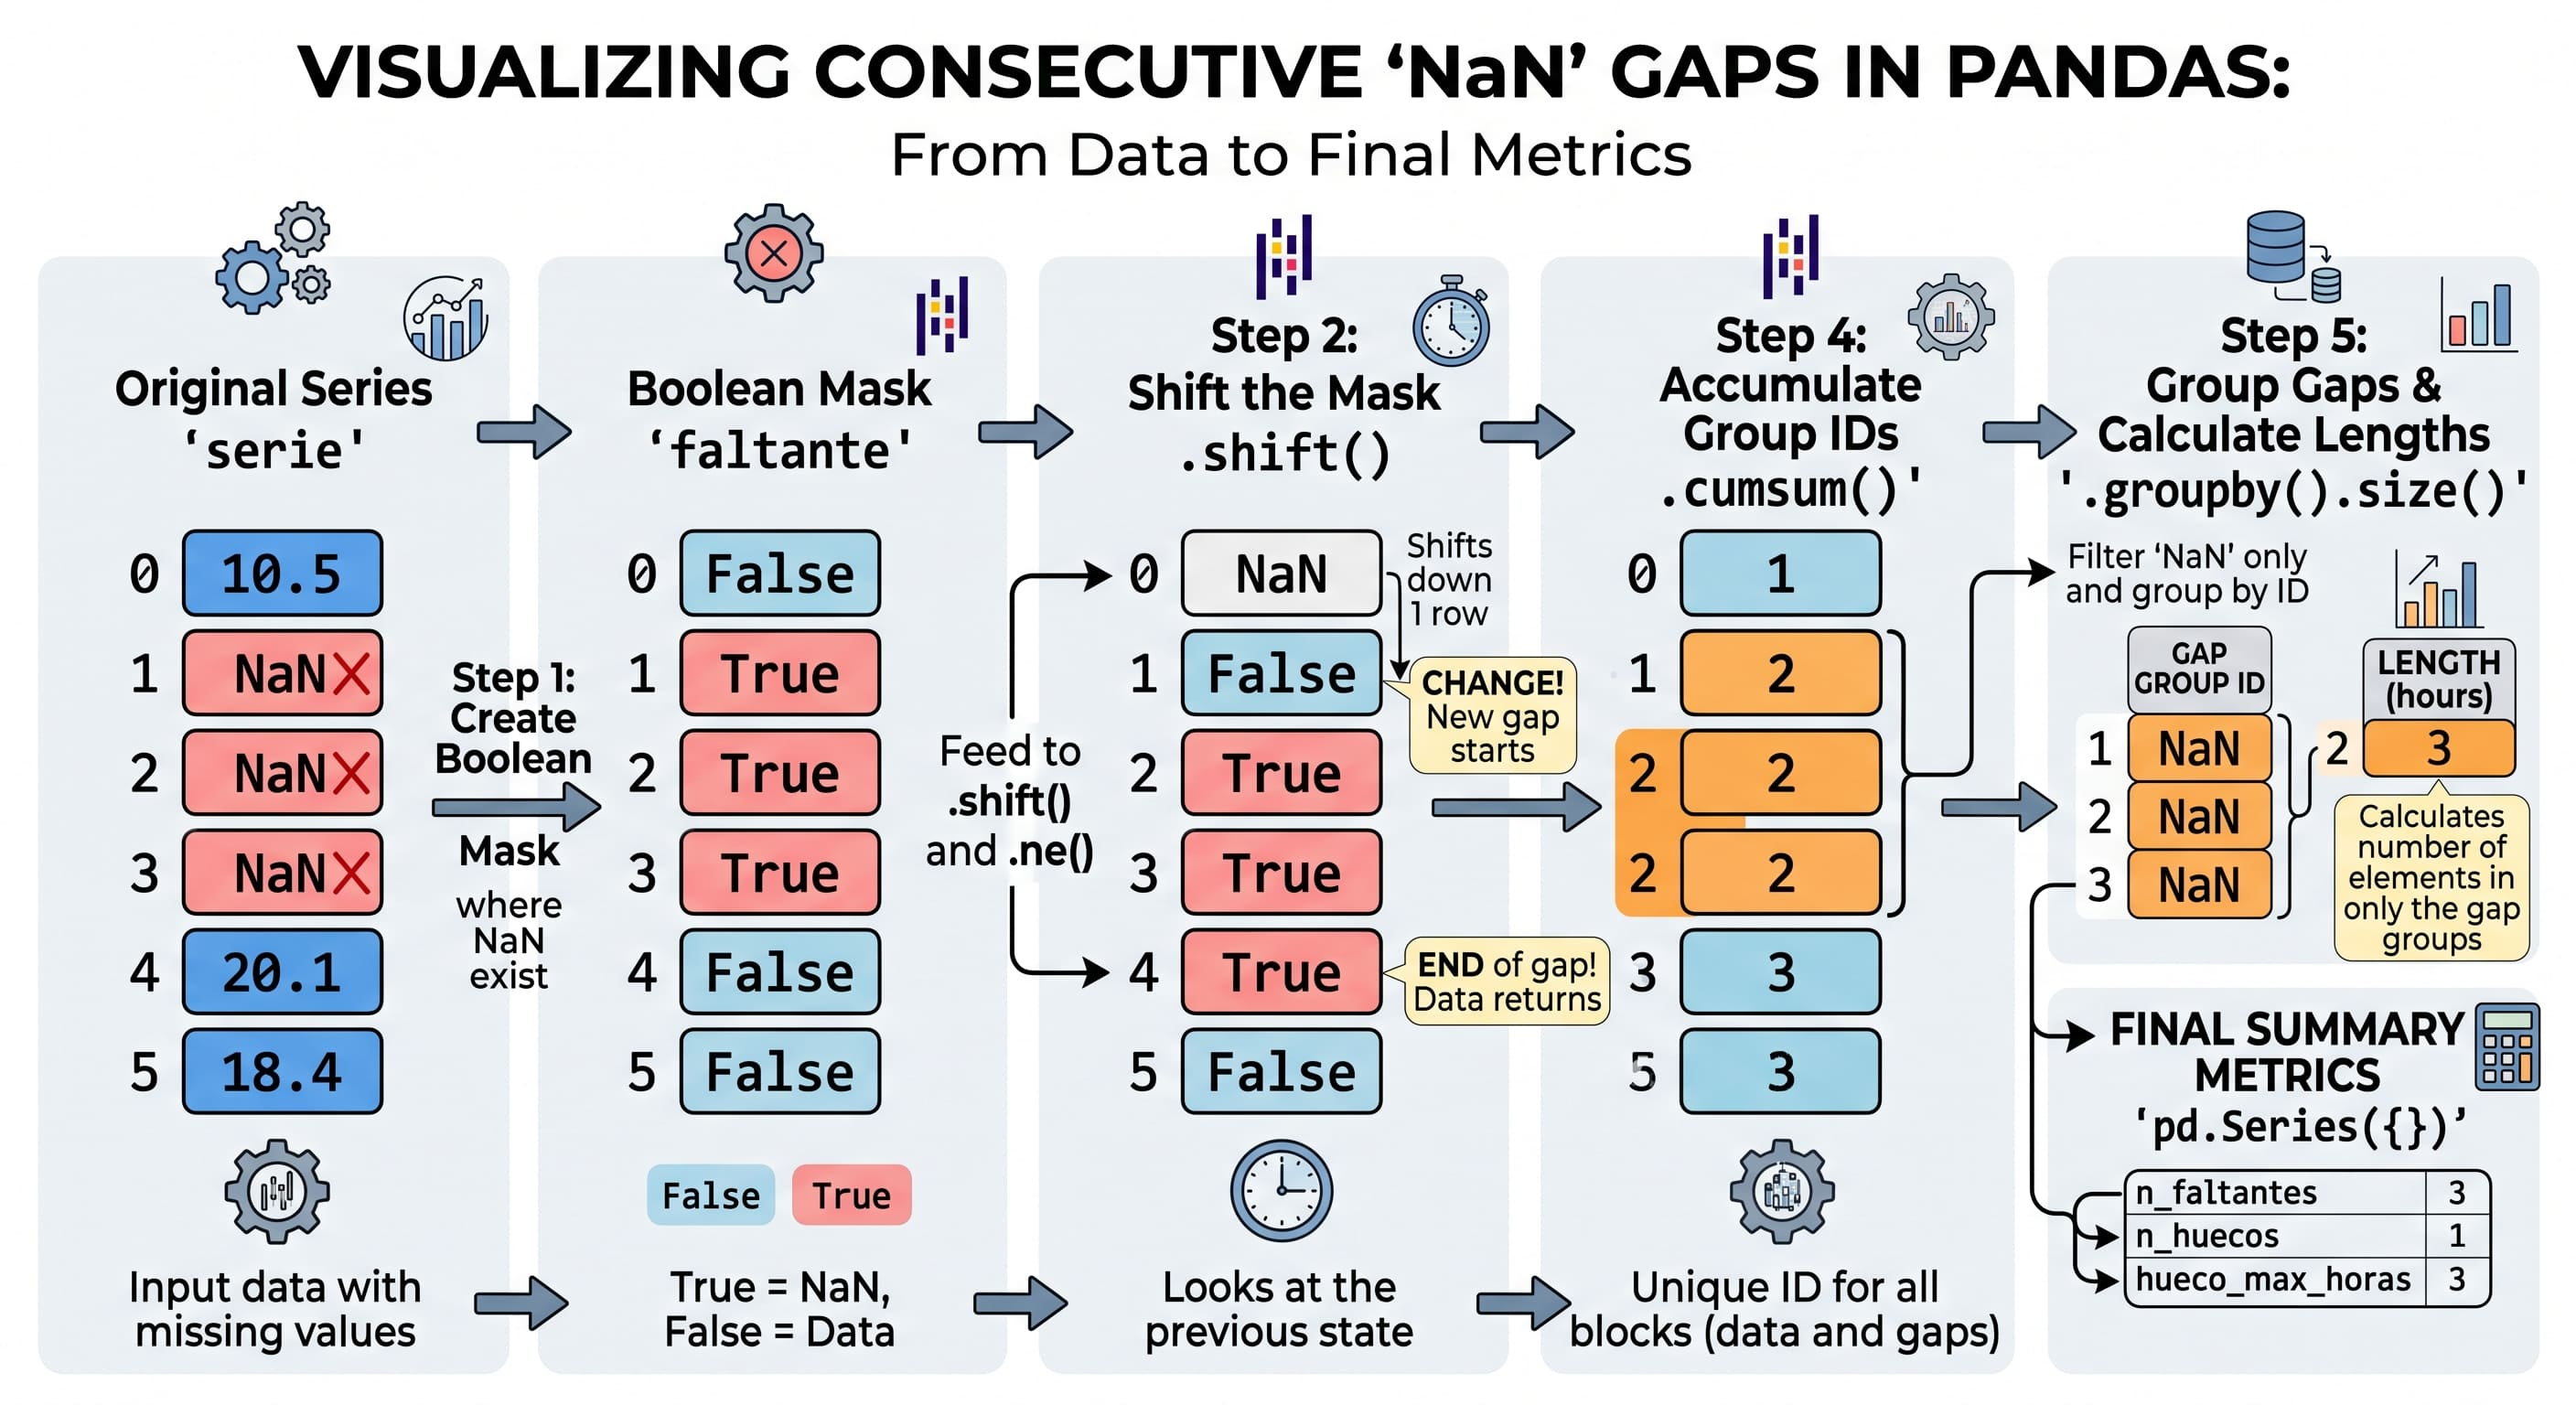

In [21]:
o3_temporal['CUA']

timestamp
2026-01-01 01:00:00    22.0
2026-01-01 02:00:00    14.0
2026-01-01 03:00:00    13.0
2026-01-01 04:00:00    10.0
2026-01-01 05:00:00    17.0
                       ... 
2026-02-28 20:00:00     NaN
2026-02-28 21:00:00     NaN
2026-02-28 22:00:00     NaN
2026-02-28 23:00:00     NaN
2026-03-01 00:00:00     NaN
Name: CUA, Length: 1416, dtype: float64

In [22]:
def resumen_huecos(serie):
    
    faltante = serie.isna()

    # Si no existen faltantes
    if faltante.sum() == 0: # 
        return pd.Series({
            "n_faltantes": 0,
            "n_huecos": 0,
            "hueco_max_horas": 0
        })

    # Identificador de bloques consecutivos
    grupos = faltante.ne(faltante.shift()).cumsum()

    # Longitud de cada bloque compuesto por NaN
    longitudes = (
        faltante[faltante]
        .groupby(grupos[faltante])
        .size()
    )

    return pd.Series({
        "n_faltantes": int(faltante.sum()),
        "n_huecos": len(longitudes),
        "hueco_max_horas": int(longitudes.max())
    })

In [23]:
huecos = pd.DataFrame({
    estacion: resumen_huecos(o3_temporal[estacion])
    for estacion in estaciones
}).T

huecos

,n_faltantes,n_huecos,hueco_max_horas
ACO,366,14,158
AJM,49,17,10
AJU,1416,1,1416
ATI,52,17,7
BJU,129,14,86
CAM,1305,2,1304
CCA,234,9,208
CHO,1416,1,1416
COY,1416,1,1416
CUA,769,5,756


In [24]:
# Incorporamos la cobertura calculada anteriormente
huecos["cobertura_pct"] = cobertura["cobertura_pct"]

# Convertimos el hueco máximo a días
huecos["hueco_max_dias"] = huecos["hueco_max_horas"] / 24




# Ordenamos por cobertura

huecos = huecos[
    [
        "cobertura_pct",
        "n_faltantes",
        "n_huecos",
        "hueco_max_horas",
        "hueco_max_dias"
    ]
].sort_values("cobertura_pct")

huecos.round(2)

,cobertura_pct,n_faltantes,n_huecos,hueco_max_horas,hueco_max_dias
AJU,0.00,1416,1,1416,59.00
SJA,0.00,1416,1,1416,59.00
SFE,0.00,1416,1,1416,59.00
CHO,0.00,1416,1,1416,59.00
COY,0.00,1416,1,1416,59.00
FAR,0.00,1416,1,1416,59.00
MPA,0.00,1416,1,1416,59.00
IZT,0.00,1416,1,1416,59.00
CAM,7.84,1305,2,1304,54.33
TAH,35.24,917,8,888,37.00


In [25]:
print("\nHuecos en estaciones con cobertura >= 90%:")

display(
    huecos[
        huecos["cobertura_pct"] >= 90
    ].sort_values("hueco_max_horas",ascending=False).round(2)
)


Huecos en estaciones con cobertura >= 90%:


,cobertura_pct,n_faltantes,n_huecos,hueco_max_horas,hueco_max_dias
LPR,91.60,119,9,97,4.04
BJU,90.89,129,14,86,3.58
NEZ,90.47,135,16,70,2.92
CUT,95.13,69,7,52,2.17
TLA,93.08,98,10,37,1.54
MER,92.23,110,16,33,1.38
UAX,95.69,61,11,30,1.25
INN,94.49,78,15,30,1.25
VIF,93.22,96,20,30,1.25
GAM,95.13,69,17,28,1.17


## 26. Localización temporal de los huecos más largos

Conocer la longitud del hueco máximo es útil, pero también necesitamos saber **cuándo ocurrió**.

Para una estación $i$, un hueco temporal puede representarse mediante el intervalo

$$
[t_{\mathrm{inicio}},t_{\mathrm{fin}}],
$$

durante el cual las mediciones permanecen ausentes de manera consecutiva.

Como nuestra base tiene frecuencia horaria, si un hueco contiene $g$ registros consecutivos faltantes, entonces su duración es

$$
g\text{ horas}.
$$

Localizar estos intervalos permite responder preguntas como:

- ¿la interrupción ocurrió al inicio, a la mitad o al final del periodo?
- ¿varias estaciones dejaron de reportar simultáneamente?
- ¿el faltante parece ser un evento aislado de una estación?
- ¿existen periodos completos que deberían tratarse con precaución?

Por ejemplo, anteriormente encontramos que la estación `LPR` presenta un hueco máximo de

$$
97\text{ horas}\approx4.04\text{ días}.
$$

Ahora determinaremos la fecha y hora de inicio y final de la interrupción más larga para cada estación con cobertura mayor o igual al $90\%$.

Este diagnóstico resulta particularmente importante antes de considerar cualquier procedimiento de imputación: un hueco de pocas horas y una interrupción de varios días no deberían tratarse automáticamente de la misma manera.

In [26]:
# Función para localizar el hueco consecutivo más largo

def localizar_hueco_maximo(serie):

    faltante = serie.isna()

    # Caso sin valores faltantes
    if not faltante.any():
        return pd.Series({
            "inicio_hueco": pd.NaT,
            "fin_hueco": pd.NaT,
            "duracion_horas": 0
        })

    # Identificamos bloques consecutivos
    grupos = faltante.ne(faltante.shift()).cumsum()

    # Longitud de cada bloque de valores faltantes
    longitudes = (
        faltante[faltante]
        .groupby(grupos[faltante])
        .size()
    )

    # Identificador del bloque más largo
    grupo_maximo = longitudes.idxmax()

    # Fechas pertenecientes al hueco más largo
    fechas_hueco = serie.index[
        (grupos == grupo_maximo) & faltante
    ]

    return pd.Series({
        "inicio_hueco": fechas_hueco.min(),
        "fin_hueco": fechas_hueco.max(),
        "duracion_horas": len(fechas_hueco)
    })

In [27]:
# estaciones con cobertura >= 90%

estaciones_90 = cobertura.index[
    cobertura["cobertura_pct"] >= 90
]

# Localizamos el mayor hueco de cada estación

intervalos_huecos = pd.DataFrame({
    estacion: localizar_hueco_maximo(
        o3_temporal[estacion]
    )
    for estacion in estaciones_90
}).T

intervalos_huecos

,inicio_hueco,fin_hueco,duracion_horas
PED,2026-01-27 12:00:00,2026-01-27 22:00:00,11
MGH,2026-01-18 00:00:00,2026-01-18 03:00:00,4
HGM,2026-01-16 12:00:00,2026-01-16 16:00:00,5
FAC,2026-01-15 12:00:00,2026-01-15 15:00:00,4
UIZ,2026-02-28 20:00:00,2026-03-01 00:00:00,5
AJM,2026-02-05 01:00:00,2026-02-05 10:00:00,10
ATI,2026-01-16 10:00:00,2026-01-16 16:00:00,7
LLA,2026-01-29 05:00:00,2026-01-30 03:00:00,23
UAX,2026-01-05 13:00:00,2026-01-06 18:00:00,30
CUT,2026-02-18 12:00:00,2026-02-20 15:00:00,52


In [28]:
# Agregamos información de cobertura
intervalos_huecos["cobertura_pct"] = (
    cobertura.loc[
        intervalos_huecos.index,
        "cobertura_pct"
    ]
)

intervalos_huecos["duracion_dias"] = (
    intervalos_huecos["duracion_horas"] / 24
)


# Ordenamos de mayor a menor duración
intervalos_huecos = (
    intervalos_huecos[
        [
            "cobertura_pct",
            "inicio_hueco",
            "fin_hueco",
            "duracion_horas",
            "duracion_dias"
        ]
    ]
    .sort_values("duracion_horas",ascending=False)
)


print("Hueco temporal más largo por estación:")
intervalos_huecos.round(2)

Hueco temporal más largo por estación:


,cobertura_pct,inicio_hueco,fin_hueco,duracion_horas,duracion_dias
LPR,91.60,2026-02-25 00:00:00,2026-03-01 00:00:00,97,4.041667
BJU,90.89,2026-02-25 11:00:00,2026-03-01 00:00:00,86,3.583333
NEZ,90.47,2026-02-01 03:00:00,2026-02-04 00:00:00,70,2.916667
CUT,95.13,2026-02-18 12:00:00,2026-02-20 15:00:00,52,2.166667
TLA,93.08,2026-02-11 01:00:00,2026-02-12 13:00:00,37,1.541667
MER,92.23,2026-02-22 16:00:00,2026-02-24 00:00:00,33,1.375
UAX,95.69,2026-01-05 13:00:00,2026-01-06 18:00:00,30,1.25
INN,94.49,2026-02-04 12:00:00,2026-02-05 17:00:00,30,1.25
VIF,93.22,2026-01-29 19:00:00,2026-01-31 00:00:00,30,1.25
GAM,95.13,2026-02-05 00:00:00,2026-02-06 03:00:00,28,1.166667


## 27. Visualización de la disponibilidad temporal

Las tablas anteriores resumen la cantidad y duración de los valores faltantes, pero no permiten apreciar fácilmente su distribución a lo largo del periodo de estudio.

Para visualizarla construiremos una matriz binaria de disponibilidad:

$$
A_{i,t}=
\begin{cases}
1, & \text{si la estación } i \text{ tiene una medición en } t,\\
0, & \text{si la medición está ausente}.
\end{cases}
$$

Las filas de esta matriz representan estaciones y las columnas representan instantes horarios.

Una representación gráfica de $A_{i,t}$ permite identificar rápidamente:

- estaciones prácticamente completas;
- estaciones con interrupciones prolongadas;
- faltantes aislados;
- periodos en los que varias estaciones dejan de reportar simultáneamente;
- estaciones sin información durante todo el periodo.

Este tipo de visualización es especialmente útil porque dos estaciones con porcentajes de cobertura similares pueden presentar patrones temporales muy diferentes.

En esta visualización incluiremos únicamente las estaciones que tienen al menos una observación válida. Las estaciones con cobertura de $0\%$ ya fueron identificadas y no aportan estructura temporal adicional al gráfico.

In [29]:
# Seleccionamos estaciones con al menos una observación válida
estaciones_con_datos = cobertura.index[
    cobertura["n_disponibles"] > 0
]

# 1 = dato disponible
# 0 = dato faltante
matriz_disponibilidad = (
    o3_temporal[estaciones_con_datos]
    .notna().astype(int).T
)

matriz_disponibilidad.head()

timestamp,2026-01-01 01:00:00,2026-01-01 02:00:00,2026-01-01 03:00:00,2026-01-01 04:00:00,2026-01-01 05:00:00,2026-01-01 06:00:00,2026-01-01 07:00:00,2026-01-01 08:00:00,2026-01-01 09:00:00,2026-01-01 10:00:00,...,2026-02-28 15:00:00,2026-02-28 16:00:00,2026-02-28 17:00:00,2026-02-28 18:00:00,2026-02-28 19:00:00,2026-02-28 20:00:00,2026-02-28 21:00:00,2026-02-28 22:00:00,2026-02-28 23:00:00,2026-03-01 00:00:00
PED,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
MGH,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
HGM,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
FAC,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
UIZ,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,0,0,0,0,0


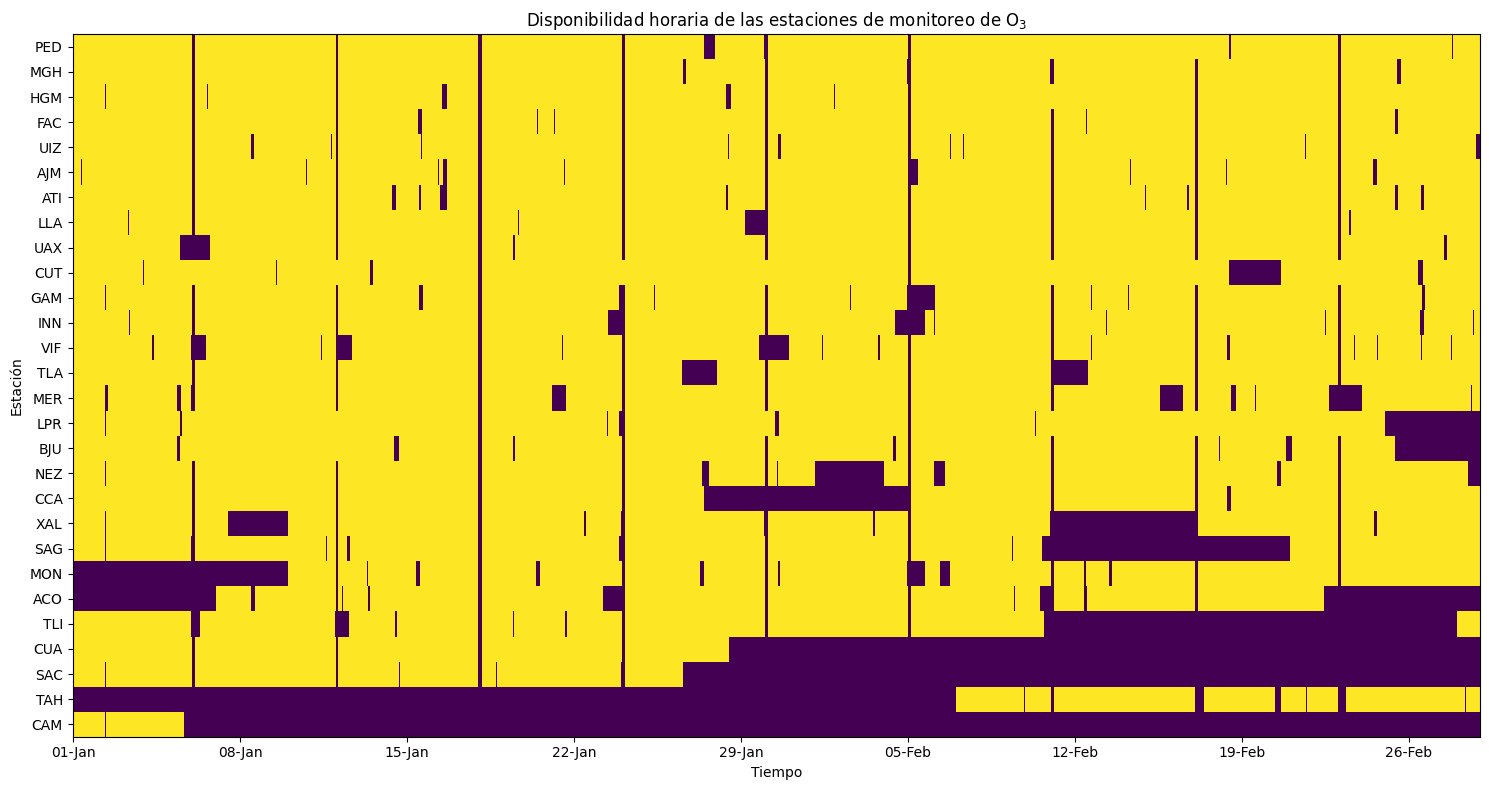

In [30]:
fig, ax = plt.subplots(figsize=(15, 8))

ax.imshow(
    matriz_disponibilidad,
    aspect="auto",
    interpolation="nearest"
)

ax.set_ylabel("Estación")
ax.set_xlabel("Tiempo")
ax.set_title(
    "Disponibilidad horaria de las estaciones de monitoreo de O$_3$"
)


ax.set_yticks(
    np.arange(len(matriz_disponibilidad.index))
)

ax.set_yticklabels(
    matriz_disponibilidad.index
)

paso = 24 * 7

posiciones = np.arange(
    0,
    len(o3_temporal),
    paso
)

etiquetas = (
    o3_temporal.index[posiciones]
    .strftime("%d-%b")
)

ax.set_xticks(posiciones)
ax.set_xticklabels(
    etiquetas
)

plt.tight_layout()
plt.show()

## 28. Disponibilidad simultánea de la red de monitoreo

Hasta ahora hemos estudiado la disponibilidad desde el punto de vista de cada estación.

Ahora cambiaremos la perspectiva y analizaremos la red completa en cada instante temporal.

Para cada hora $t$, definimos

$$
N_t
=
\sum_{i=1}^{m} A_{i,t},
$$

donde

$$
A_{i,t}
=
\begin{cases}
1, & \text{si la estación } i \text{ reportó una medición válida},\\
0, & \text{si la medición está ausente}.
\end{cases}
$$

Por tanto, $N_t$ representa el **número de estaciones disponibles simultáneamente** en la hora $t$.

En esta base existen estaciones que no presentan ninguna medición durante todo el periodo. Para estudiar la disponibilidad efectiva de la red utilizaremos únicamente las estaciones que contienen al menos una observación válida.

Si denotamos por $m^\ast$ el número de estas estaciones, también podemos calcular

$$
P_t
=
\frac{N_t}{m^\ast}\times100,
$$

que representa el porcentaje de estaciones disponibles en cada instante.

Este análisis permite detectar:

- periodos con alta disponibilidad de la red;
- horas en las que disminuye considerablemente el número de estaciones activas;
- interrupciones simultáneas;
- posibles periodos que podrían ser problemáticos para análisis espaciales o multivariados.

Es importante distinguir este indicador de la cobertura individual: una estación puede tener buena cobertura global, pero coincidir con otras estaciones en un periodo de pérdida simultánea de información.

In [31]:
# Estaciones con al menos una medición válida
estaciones_activas = cobertura.index[
    cobertura["n_disponibles"] > 0
]

n_estaciones_activas = len(estaciones_activas)

print("Número total de estaciones en la base:")
print(len(estaciones))

print("\nEstaciones con al menos una medición válida:")
print(n_estaciones_activas)

Número total de estaciones en la base:
36

Estaciones con al menos una medición válida:
28


In [32]:
disponibilidad_red = pd.DataFrame(
    index=o3_temporal.index
)

disponibilidad_red["n_estaciones"] = (
    o3_temporal[estaciones_activas]
    .notna()
    .sum(axis=1)
)

disponibilidad_red["porcentaje"] = (
    disponibilidad_red["n_estaciones"]
    / n_estaciones_activas
    * 100
)

disponibilidad_red

,n_estaciones,porcentaje
timestamp,,
2026-01-01 01:00:00,25,89.285714
2026-01-01 02:00:00,25,89.285714
2026-01-01 03:00:00,25,89.285714
2026-01-01 04:00:00,25,89.285714
2026-01-01 05:00:00,25,89.285714
...,...,...
2026-02-28 20:00:00,20,71.428571
2026-02-28 21:00:00,20,71.428571
2026-02-28 22:00:00,20,71.428571


In [33]:
print("\nResumen del número de estaciones disponibles por hora:")

display(
    disponibilidad_red["n_estaciones"]
    .describe()
    .round(2)
    .to_frame()
)

print("\nResumen del porcentaje de disponibilidad de la red:")

display(
    disponibilidad_red["porcentaje"]
    .describe()
    .round(2)
    .to_frame()
)


Resumen del número de estaciones disponibles por hora:


,n_estaciones
count,1416.00
mean,23.06
std,3.55
min,0.00
25%,22.00
50%,23.00
75%,25.00
max,26.00



Resumen del porcentaje de disponibilidad de la red:


,porcentaje
count,1416.00
mean,82.37
std,12.70
min,0.00
25%,78.57
50%,82.14
75%,89.29
max,92.86


In [34]:
# Instantes con menor disponibilidad

minimo_estaciones = (
    disponibilidad_red["n_estaciones"].min()
)

print("\nMenor número de estaciones disponibles simultáneamente:")
print(minimo_estaciones)

print("\nInstantes en los que se alcanzó ese mínimo:")

display(
    disponibilidad_red[
        disponibilidad_red["n_estaciones"]
        == minimo_estaciones
    ].head(20)
)


Menor número de estaciones disponibles simultáneamente:
0

Instantes en los que se alcanzó ese mínimo:


,n_estaciones,porcentaje
timestamp,,
2026-01-18 00:00:00,0,0.0
2026-01-18 01:00:00,0,0.0
2026-01-18 02:00:00,0,0.0
2026-01-18 03:00:00,0,0.0
2026-02-05 01:00:00,0,0.0
2026-02-05 02:00:00,0,0.0
2026-02-05 03:00:00,0,0.0


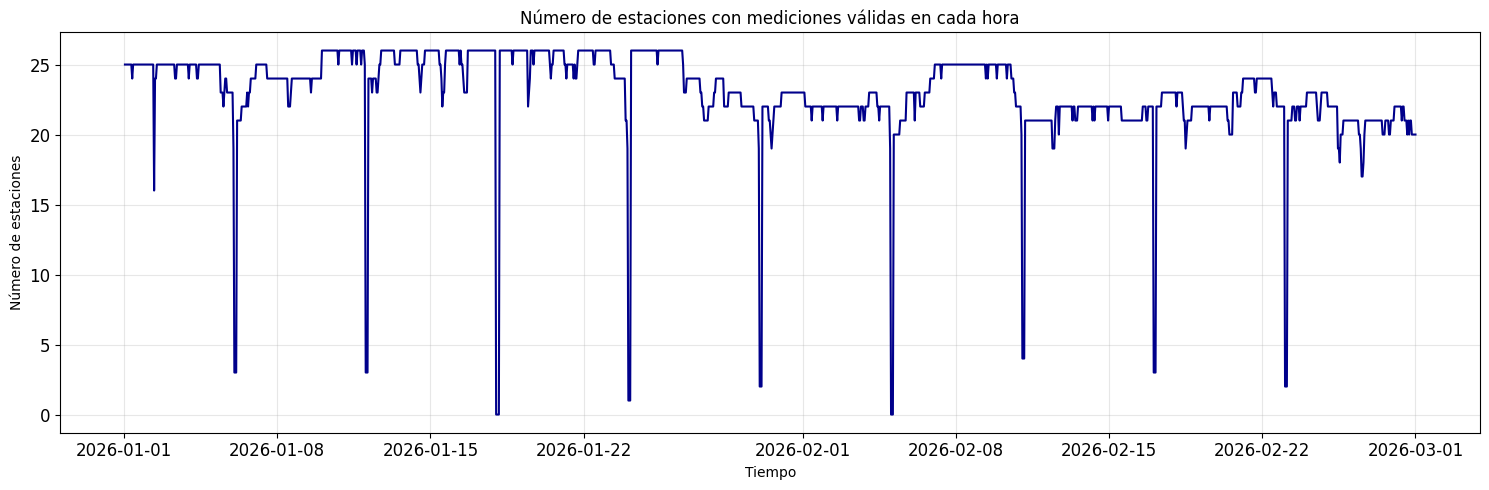

In [36]:
# Evolución temporal

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    disponibilidad_red.index,
    disponibilidad_red["n_estaciones"],
    color='darkblue'
)

ax.set_title(
    "Número de estaciones con mediciones válidas en cada hora"
)

ax.set_xlabel("Tiempo")
ax.set_ylabel("Número de estaciones")
ax.tick_params(labelsize=12)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 29. Episodios de baja disponibilidad de la red

La disponibilidad horaria mostró que existen momentos en los que muchas estaciones dejan de reportar simultáneamente.

Para estudiar estos eventos definiremos un indicador de disponibilidad relativa:

$$
P_t=
\frac{N_t}{m^\ast}\times100,
$$

donde:

- $N_t$ es el número de estaciones con medición válida en la hora $t$;
- $m^\ast$ es el número de estaciones que tienen al menos una observación durante el periodo.

En nuestro caso,

$$
m^\ast=28.
$$

Podemos definir un **episodio de baja disponibilidad** como una secuencia de horas consecutivas durante las cuales

$$
P_t < \tau,
$$

donde $\tau$ es un umbral previamente establecido.

Para este ejercicio utilizaremos, con fines ilustrativos,

$$
\tau=50\%.
$$

Esto significa que consideraremos una caída severa cuando menos de la mitad de las estaciones activas estén reportando simultáneamente.

Para cada episodio calcularemos:

- instante de inicio;
- instante de finalización;
- duración en horas;
- número mínimo de estaciones disponibles;
- porcentaje mínimo de disponibilidad.

Es importante señalar que el umbral del $50\%$ es una decisión analítica utilizada para explorar los datos y **no constituye una regla universal**.

La identificación de estos episodios permite distinguir entre:

$$
\boxed{\text{faltantes individuales}}
$$

y

$$
\boxed{\text{interrupciones colectivas de la red}}.
$$

In [37]:
# Identificación de episodios de baja disponibilidad

umbral = 50

disponibilidad_red["baja_disponibilidad"] = (
    disponibilidad_red["porcentaje"] < umbral
)


# Identificación de bloques consecutivos

grupos = (
    disponibilidad_red["baja_disponibilidad"]
    .ne(
        disponibilidad_red["baja_disponibilidad"].shift()
    )
    .cumsum()
)


episodios = []

for _, bloque in disponibilidad_red[
    disponibilidad_red["baja_disponibilidad"]
].groupby(
    grupos[disponibilidad_red["baja_disponibilidad"]]
):

    episodios.append({
        "inicio": bloque.index.min(),
        "fin": bloque.index.max(),
        "duracion_horas": len(bloque),
        "min_estaciones": bloque["n_estaciones"].min(),
        "min_porcentaje": bloque["porcentaje"].min(),
        "media_estaciones": bloque["n_estaciones"].mean()
    })


episodios_baja_disponibilidad = pd.DataFrame(episodios)

episodios_baja_disponibilidad

,inicio,fin,duracion_horas,min_estaciones,min_porcentaje,media_estaciones
0,2026-01-06 01:00:00,2026-01-06 03:00:00,3,3,10.714286,3.0
1,2026-01-12 01:00:00,2026-01-12 03:00:00,3,3,10.714286,3.0
2,2026-01-18 00:00:00,2026-01-18 03:00:00,4,0,0.000000,0.0
3,2026-01-24 01:00:00,2026-01-24 03:00:00,3,1,3.571429,1.0
4,2026-01-30 01:00:00,2026-01-30 03:00:00,3,2,7.142857,2.0
5,2026-02-05 01:00:00,2026-02-05 03:00:00,3,0,0.000000,0.0
6,2026-02-11 01:00:00,2026-02-11 03:00:00,3,4,14.285714,4.0
7,2026-02-17 01:00:00,2026-02-17 03:00:00,3,3,10.714286,3.0
8,2026-02-23 01:00:00,2026-02-23 03:00:00,3,2,7.142857,2.0


In [38]:
print("\nNúmero de episodios de baja disponibilidad:")
len(episodios_baja_disponibilidad)


Número de episodios de baja disponibilidad:


9